# 05. 보호소 클러스터링 분석

**목적:** 564개 보호소를 운영 성과 기반으로 유형화하여 "Where가 아닌 How" 메시지를 정량적으로 뒷받침

**입력:** `02_outputs/data/agg_shelter_performance.csv`

**분석 축:** 입양률, 안락사율, 자연사율, 평균보호기간 (4개)

**방법:** K-Means 클러스터링 + PCA 시각화 + 레이더차트 프로파일링

In [1]:
# ============================================================
# 환경 설정
# ============================================================
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# 한글 폰트 설정
matplotlib.rcParams['font.family'] = 'Apple SD Gothic Neo'
matplotlib.rcParams['axes.unicode_minus'] = False

# 경로 설정
BASE_DIR = os.path.dirname(os.getcwd())
OUT_DIR = os.path.join(BASE_DIR, '02_outputs', 'data')
FIG_DIR = os.path.join(BASE_DIR, '02_outputs', 'figures', 'clustering')
os.makedirs(FIG_DIR, exist_ok=True)

print(f'BASE_DIR: {BASE_DIR}')
print(f'FIG_DIR: {FIG_DIR}')

BASE_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound
FIG_DIR: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/clustering


## 1. 데이터 로드 및 탐색

In [2]:
df = pd.read_csv(os.path.join(OUT_DIR, 'agg_shelter_performance.csv'))
print(f'보호소 수: {len(df)}')
print(f'컬럼: {list(df.columns)}')
df.head()

보호소 수: 564
컬럼: ['보호소명', '시도', '시군구', '총보호건수', '입양건수', '자연사건수', '안락사건수', '반환건수', '평균보호기간', '개비율', '고양이비율', '입양률', '안락사율', '자연사율']


,보호소명,시도,시군구,총보호건수,입양건수,자연사건수,안락사건수,반환건수,평균보호기간,개비율,고양이비율,입양률,안락사율,자연사율
0,제주 동물보호센터,제주특별자치도,제주특별자치도,34673,5167,6478,19506,1940,10.564705,87.485940,12.228535,14.90,56.26,18.68
1,평택시유기동물보호소,경기도,평택시,14827,4425,3080,4915,1359,10.137250,78.539152,18.823767,29.84,33.15,20.77
2,밀양시 동물보호센터,경상남도,밀양시,12385,3889,4024,3150,440,10.567622,85.724667,13.879693,31.40,25.43,32.49
3,익산유기동물보호소,전북특별자치도,익산시,11094,5822,3297,725,828,10.706598,72.705967,26.032089,52.48,6.54,29.72
4,화성동물보호센터,경기도,화성시,10391,2222,3504,3040,915,9.284284,86.257338,12.472332,21.38,29.26,33.72


In [3]:
# 클러스터링에 사용할 4개 피처 기초 통계
features = ['입양률', '안락사율', '자연사율', '평균보호기간']
print(df[features].describe().round(2))
print(f'\n결측치:\n{df[features].isnull().sum()}')

          입양률    안락사율    자연사율  평균보호기간
count  564.00  564.00  564.00  564.00
mean    36.99   18.87   23.83   10.54
std     24.19   21.72   19.98    4.77
min      0.00    0.00    0.00    0.00
25%     20.27    0.39    7.89   10.05
50%     32.03   12.51   21.38   10.55
75%     50.00   29.60   34.30   10.67
max    100.00  100.00  100.00  116.83

결측치:
입양률       0
안락사율      0
자연사율      0
평균보호기간    0
dtype: int64


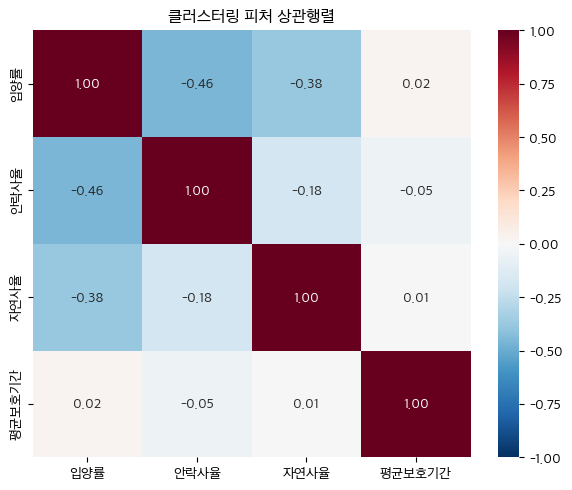

In [4]:
# 피처 간 상관관계
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('클러스터링 피처 상관행렬')
plt.tight_layout()
plt.show()

## 2. 전처리 — StandardScaler 정규화

In [5]:
X = df[features].copy()

# 결측치 처리
X = X.fillna(X.median())

# 이상치 클리핑 (평균보호기간 99퍼센타일 기준)
p99 = X['평균보호기간'].quantile(0.99)
print(f'평균보호기간 99퍼센타일: {p99:.2f}')
outlier_mask = X['평균보호기간'] > p99
print(f'이상치 보호소: {outlier_mask.sum()}개')
if outlier_mask.any():
    print(f'  → {df.loc[outlier_mask, "보호소명"].tolist()} (클리핑 처리)')
X['평균보호기간'] = X['평균보호기간'].clip(upper=p99)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\n정규화 후 평균: {X_scaled.mean(axis=0).round(4)}')
print(f'정규화 후 표준편차: {X_scaled.std(axis=0).round(4)}')

평균보호기간 99퍼센타일: 15.64
이상치 보호소: 6개
  → ['한국야생동물보호협회', '한국동물구조관리협회', '한국동물구조관리협회', '동대문구청', '서초동물사랑센터', '서울동물복지지원센터'] (클리핑 처리)

정규화 후 평균: [-0.  0.  0.  0.]
정규화 후 표준편차: [1. 1. 1. 1.]


## 3. 최적 K 결정 — Elbow, Silhouette, Calinski-Harabasz

In [6]:
K_range = range(2, 11)
inertias = []
sil_scores = []
ch_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    print(f'K={k}: Inertia={km.inertia_:.1f}, Silhouette={sil_scores[-1]:.4f}, CH={ch_scores[-1]:.1f}')

K=2: Inertia=1685.1, Silhouette=0.2618, CH=190.4
K=3: Inertia=1285.8, Silhouette=0.2899, CH=211.7
K=4: Inertia=1075.1, Silhouette=0.3130, CH=205.0
K=5: Inertia=870.5, Silhouette=0.3033, CH=222.4
K=6: Inertia=746.9, Silhouette=0.3203, CH=225.5
K=7: Inertia=662.9, Silhouette=0.3050, CH=223.1
K=8: Inertia=584.1, Silhouette=0.3327, CH=227.4
K=9: Inertia=528.6, Silhouette=0.3098, CH=226.7
K=10: Inertia=485.5, Silhouette=0.3165, CH=224.5


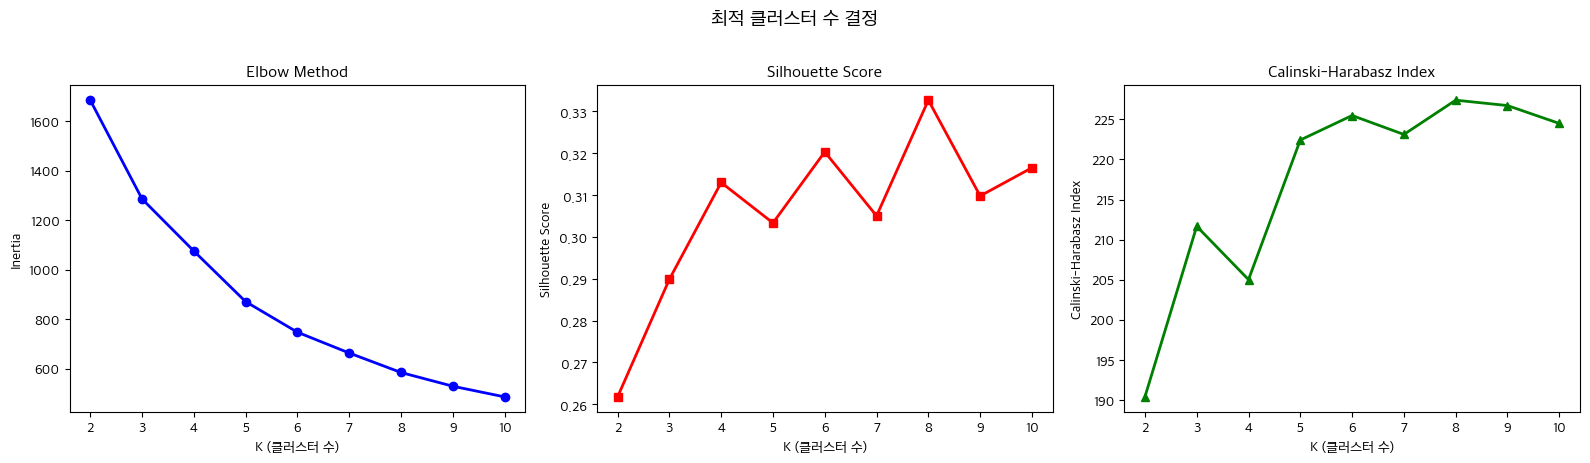


Silhouette Score 최대 K = 8 (Score = 0.3327)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('K (클러스터 수)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

# Silhouette
axes[1].plot(K_range, sil_scores, 'rs-', linewidth=2)
axes[1].set_xlabel('K (클러스터 수)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].set_xticks(list(K_range))

# Calinski-Harabasz
axes[2].plot(K_range, ch_scores, 'g^-', linewidth=2)
axes[2].set_xlabel('K (클러스터 수)')
axes[2].set_ylabel('Calinski-Harabasz Index')
axes[2].set_title('Calinski-Harabasz Index')
axes[2].set_xticks(list(K_range))

plt.suptitle('최적 클러스터 수 결정', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()

# 최적 K 선택 (Silhouette 최대)
best_k = list(K_range)[np.argmax(sil_scores)]
print(f'\nSilhouette Score 최대 K = {best_k} (Score = {max(sil_scores):.4f})')

## 4. K-Means 클러스터링 실행

In [8]:
# Silhouette 최대 K 사용, 단 해석력 고려하여 3~5 범위 내에서 결정
# best_k가 해석에 적합하지 않으면 조정
OPTIMAL_K = best_k if 3 <= best_k <= 5 else 4
print(f'최종 선택 K = {OPTIMAL_K}')

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20, max_iter=500)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'\n클러스터별 보호소 수:')
print(df['cluster'].value_counts().sort_index())
print(f'\nSilhouette Score: {silhouette_score(X_scaled, df["cluster"]):.4f}')

최종 선택 K = 4

클러스터별 보호소 수:
cluster
0     53
1    177
2    113
3    221
Name: count, dtype: int64

Silhouette Score: 0.3130


## 5. 클러스터 프로파일링

In [9]:
# 클러스터별 평균/표준편차 프로파일
profile = df.groupby('cluster')[features].agg(['mean', 'std']).round(2)
print('=== 클러스터 프로파일 (평균 ± 표준편차) ===')
display(profile)

# 간결한 평균 테이블
profile_mean = df.groupby('cluster')[features].mean().round(2)
profile_mean['보호소수'] = df.groupby('cluster').size().values
profile_mean['총보호건수_평균'] = df.groupby('cluster')['총보호건수'].mean().round(0).values
print('\n=== 클러스터 요약 ===')
display(profile_mean)

=== 클러스터 프로파일 (평균 ± 표준편차) ===


입양률          안락사율          자연사율        평균보호기간      
          mean    std   mean    std   mean    std   mean   std
cluster                                                       
0        43.85  23.57  18.29  16.56  11.33  11.43   7.13  1.27
1        61.41  20.72   5.96   8.16  11.67  10.01  11.23  8.05
2        20.15  10.64  53.25  19.19  17.10  10.65  10.49  1.18
3        24.41  13.01  11.78  10.46  40.00  20.26  10.82  1.39


=== 클러스터 요약 ===


,입양률,안락사율,자연사율,평균보호기간,보호소수,총보호건수_평균
cluster,,,,,,
0,43.85,18.29,11.33,7.13,53,618.0
1,61.41,5.96,11.67,11.23,177,945.0
2,20.15,53.25,17.10,10.49,113,1745.0
3,24.41,11.78,40.00,10.82,221,1777.0


In [10]:
# 클러스터별 명칭 부여 (프로파일 기반 — 핵심 지표 순위로 판정)
cluster_means = df.groupby('cluster')[features].mean()

cluster_labels = {}
for c in range(OPTIMAL_K):
    row = cluster_means.loc[c]
    # 가장 두드러진 특성 기준으로 라벨링
    adoption_rank = cluster_means['입양률'].rank(ascending=False)[c]
    euthanasia_rank = cluster_means['안락사율'].rank(ascending=False)[c]
    natural_rank = cluster_means['자연사율'].rank(ascending=False)[c]
    
    if adoption_rank == 1:
        label = '적극입양형'
    elif euthanasia_rank == 1:
        label = '고안락사형'
    elif natural_rank == 1:
        label = '고자연사형'
    else:
        label = '균형관리형'
    cluster_labels[c] = f'C{c}: {label}'

df['cluster_label'] = df['cluster'].map(cluster_labels)
print('클러스터 라벨:')
for k, v in cluster_labels.items():
    n = (df['cluster'] == k).sum()
    m = cluster_means.loc[k]
    print(f'  {v} ({n}개) — 입양률 {m["입양률"]:.1f}%, 안락사율 {m["안락사율"]:.1f}%, 자연사율 {m["자연사율"]:.1f}%')

클러스터 라벨:
  C0: 균형관리형 (53개) — 입양률 43.8%, 안락사율 18.3%, 자연사율 11.3%
  C1: 적극입양형 (177개) — 입양률 61.4%, 안락사율 6.0%, 자연사율 11.7%
  C2: 고안락사형 (113개) — 입양률 20.1%, 안락사율 53.3%, 자연사율 17.1%
  C3: 고자연사형 (221개) — 입양률 24.4%, 안락사율 11.8%, 자연사율 40.0%


In [11]:
# 클러스터별 대표 보호소 (총보호건수 상위 3개)
print('=== 클러스터별 대표 보호소 (규모 상위 3개) ===')
for c in range(OPTIMAL_K):
    sub = df[df['cluster'] == c].nlargest(3, '총보호건수')[['보호소명','시도','총보호건수'] + features]
    print(f'\n--- {cluster_labels[c]} ---')
    display(sub)

=== 클러스터별 대표 보호소 (규모 상위 3개) ===

--- C0: 균형관리형 ---


,보호소명,시도,총보호건수,입양률,안락사율,자연사율,평균보호기간
46,서산시 동물보호센터,충청남도,3946,22.93,44.45,16.52,7.427775
47,금일동물보호센터,충청남도,3829,48.42,11.28,23.77,7.337947
48,정선가축병원,강원특별자치도,3809,38.65,36.02,23.44,7.127593



--- C1: 적극입양형 ---


,보호소명,시도,총보호건수,입양률,안락사율,자연사율,평균보호기간
3,익산유기동물보호소,전북특별자치도,11094,52.48,6.54,29.72,10.706598
6,반려동물보호센터,충청북도,9865,46.76,14.59,11.67,10.543234
7,(사)영일동물플러스,경상북도,9271,48.87,22.01,16.20,10.269550



--- C2: 고안락사형 ---


,보호소명,시도,총보호건수,입양률,안락사율,자연사율,평균보호기간
0,제주 동물보호센터,제주특별자치도,34673,14.90,56.26,18.68,10.564705
1,평택시유기동물보호소,경기도,14827,29.84,33.15,20.77,10.137250
8,한국동물구조관리협회,경기도,8253,17.91,57.03,15.92,10.616988



--- C3: 고자연사형 ---


,보호소명,시도,총보호건수,입양률,안락사율,자연사율,평균보호기간
2,밀양시 동물보호센터,경상남도,12385,31.40,25.43,32.49,10.567622
4,화성동물보호센터,경기도,10391,21.38,29.26,33.72,9.284284
5,군산유기동물보호센터,전북특별자치도,9939,38.09,16.36,34.57,11.912567


## 6. PCA 2D 투영 산점도

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA 설명 분산: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')
print(f'누적 설명 분산: {pca.explained_variance_ratio_.sum():.3f}')

# PCA 로딩 확인
loadings = pd.DataFrame(pca.components_.T, index=features, columns=['PC1', 'PC2'])
print('\nPCA 로딩:')
display(loadings.round(3))

PCA 설명 분산: PC1=0.380, PC2=0.315
누적 설명 분산: 0.695

PCA 로딩:


,PC1,PC2
입양률,0.749,0.032
안락사율,-0.507,-0.597
자연사율,-0.402,0.649
평균보호기간,-0.141,0.470


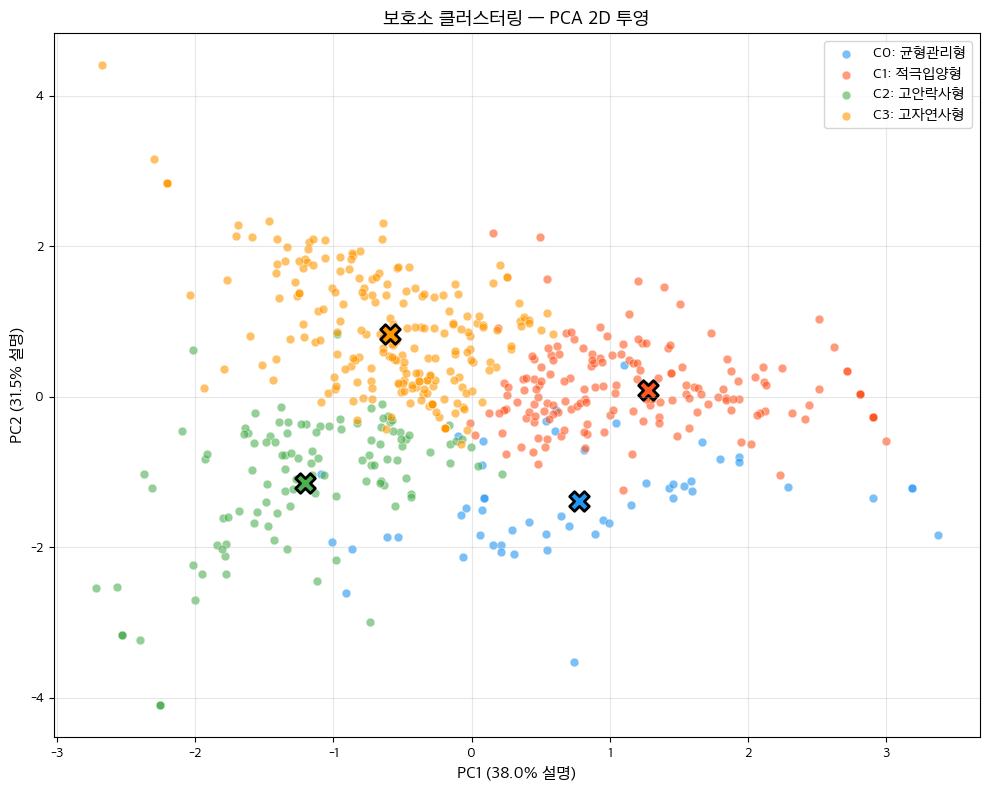

In [13]:
colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(10, 8))
for c in range(OPTIMAL_K):
    mask = df['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[c], label=cluster_labels[c],
               alpha=0.6, s=40, edgecolors='white', linewidth=0.5)

# 클러스터 중심 표시
centers_pca = pca.transform(kmeans.cluster_centers_)
for c in range(OPTIMAL_K):
    ax.scatter(centers_pca[c, 0], centers_pca[c, 1],
               c=colors[c], marker='X', s=200, edgecolors='black', linewidth=2)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} 설명)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} 설명)', fontsize=12)
ax.set_title('보호소 클러스터링 — PCA 2D 투영', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_pca_2d.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. 레이더 차트 (클러스터별 프로파일 비교)

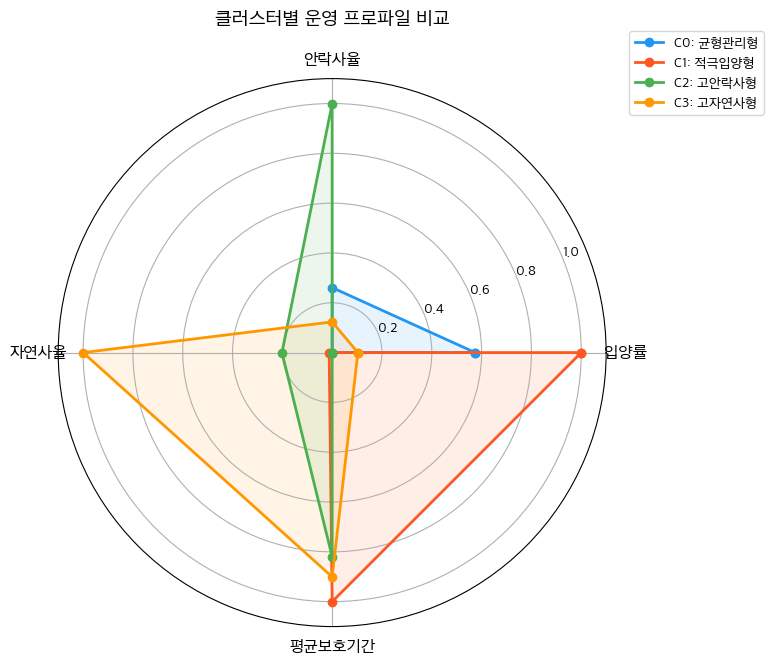

In [14]:
# 클러스터별 평균을 0-1 MinMax 정규화하여 레이더차트 생성
from matplotlib.patches import FancyBboxPatch

means = df.groupby('cluster')[features].mean()
# 0-1 정규화 (레이더차트 비교용)
means_norm = (means - means.min()) / (means.max() - means.min())

categories = features
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # 닫기

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for c in range(OPTIMAL_K):
    values = means_norm.loc[c].tolist()
    values += values[:1]  # 닫기
    ax.plot(angles, values, 'o-', linewidth=2, label=cluster_labels[c], color=colors[c])
    ax.fill(angles, values, alpha=0.1, color=colors[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('클러스터별 운영 프로파일 비교', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cluster_radar.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. 평행좌표 플롯

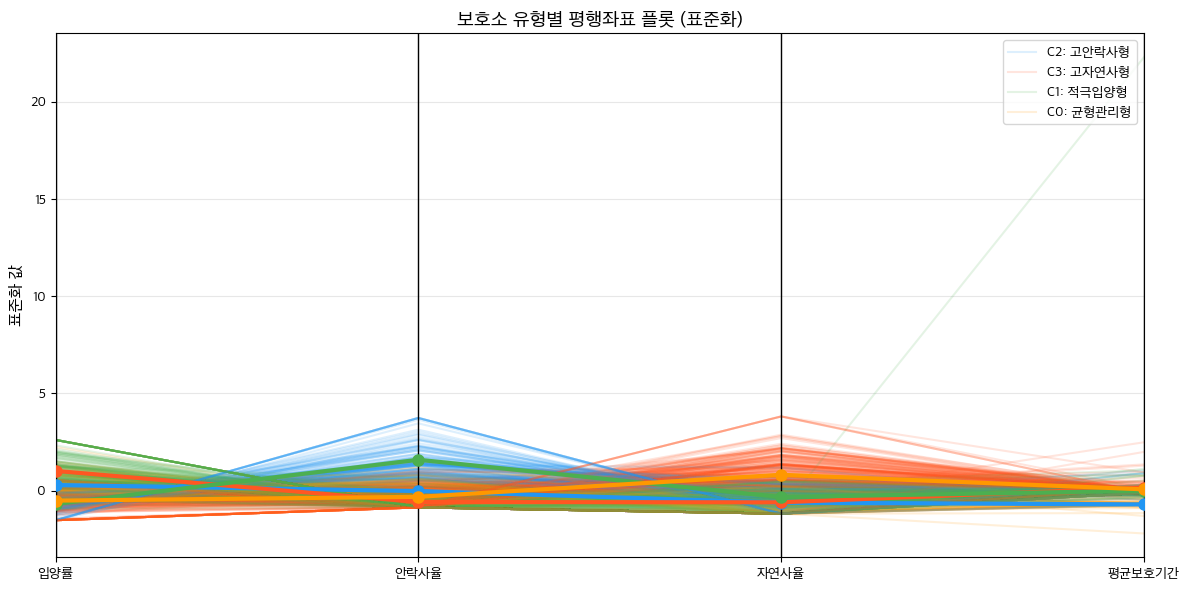

In [15]:
from pandas.plotting import parallel_coordinates

# 평행좌표용 데이터 준비 (정규화된 값)
df_parallel = df[features + ['cluster_label']].copy()
for col in features:
    df_parallel[col] = (df_parallel[col] - df_parallel[col].mean()) / df_parallel[col].std()

fig, ax = plt.subplots(figsize=(12, 6))
parallel_coordinates(df_parallel, 'cluster_label', color=colors[:OPTIMAL_K],
                     alpha=0.15, ax=ax)

# 클러스터 평균선 굵게 표시
means_std = df_parallel.groupby('cluster_label')[features].mean()
for i, (label, row) in enumerate(means_std.iterrows()):
    ax.plot(range(len(features)), row.values, color=colors[i],
            linewidth=3, marker='o', markersize=8, zorder=10)

ax.set_title('보호소 유형별 평행좌표 플롯 (표준화)', fontsize=14, fontweight='bold')
ax.set_ylabel('표준화 값', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'parallel_coordinates.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. 정책 제언 매핑

스토리텔링 v2.0의 "Where가 아닌 How" 메시지와 연결하여, 클러스터 유형별 맞춤 처방을 도출한다.

In [16]:
# 클러스터별 시도 분포
print('=== 클러스터별 시도 분포 ===')
ct = pd.crosstab(df['cluster_label'], df['시도'])
display(ct)

=== 클러스터별 시도 분포 ===


시도,강원특별자치도,경기도,경상남도,경상북도,광주광역시,대구광역시,대전광역시,부산광역시,서울특별시,세종특별자치시,울산광역시,인천광역시,전라남도,전북특별자치도,제주특별자치도,충청남도,충청북도
cluster_label,,,,,,,,,,,,,,,,,
C0: 균형관리형,3,19,3,5,1,0,0,1,6,0,0,0,1,4,0,9,1
C1: 적극입양형,3,38,9,9,2,14,5,3,34,0,10,7,2,22,4,10,5
C2: 고안락사형,10,17,12,17,0,5,0,1,1,2,0,3,12,10,1,15,7
C3: 고자연사형,8,22,13,7,7,16,5,27,40,0,19,14,15,15,2,5,6


In [17]:
# 정책 제언 테이블
policy = []
for c in range(OPTIMAL_K):
    row = cluster_means.loc[c]
    label = cluster_labels[c]
    count = (df['cluster'] == c).sum()
    
    # 유형별 맞춤 처방
    if '적극입양' in label:
        prescription = '모범 사례 벤치마크 대상. 운영 노하우 공유 프로그램 운영'
    elif '고안락사' in label:
        prescription = '안락사 대안 프로토콜 도입 시급. TNR 확대 및 협력 입양 네트워크 구축'
    elif '고자연사' in label:
        prescription = '의료 인프라 및 보호 환경 개선 우선. 수의사 상주 지원'
    else:
        prescription = '입양률 제고를 위한 홍보 강화 및 입양 절차 간소화'
    
    policy.append({
        '클러스터': label,
        '보호소수': count,
        '입양률': f"{row['입양률']:.1f}%",
        '안락사율': f"{row['안락사율']:.1f}%",
        '자연사율': f"{row['자연사율']:.1f}%",
        '정책 제언': prescription
    })

policy_df = pd.DataFrame(policy)
print('=== 클러스터별 정책 제언 ===')
display(policy_df)

=== 클러스터별 정책 제언 ===


,클러스터,보호소수,입양률,안락사율,자연사율,정책 제언
0,C0: 균형관리형,53,43.8%,18.3%,11.3%,입양률 제고를 위한 홍보 강화 및 입양 절차 간소화
1,C1: 적극입양형,177,61.4%,6.0%,11.7%,모범 사례 벤치마크 대상. 운영 노하우 공유 프로그램 운영
2,C2: 고안락사형,113,20.1%,53.3%,17.1%,안락사 대안 프로토콜 도입 시급. TNR 확대 및 협력 입양 네트워크 구축
3,C3: 고자연사형,221,24.4%,11.8%,40.0%,의료 인프라 및 보호 환경 개선 우선. 수의사 상주 지원


## 10. 결과 저장

In [18]:
# 클러스터 라벨 포함 CSV 저장
save_cols = ['보호소명', '시도', '시군구', '총보호건수', '입양건수', '자연사건수', '안락사건수',
             '반환건수', '평균보호기간', '입양률', '안락사율', '자연사율', 'cluster', 'cluster_label']
df[save_cols].to_csv(os.path.join(OUT_DIR, 'shelter_clustering_result.csv'),
                     index=False, encoding='utf-8-sig')
print(f'저장 완료: {os.path.join(OUT_DIR, "shelter_clustering_result.csv")}')
print(f'\n저장된 시각화:')
for f in os.listdir(FIG_DIR):
    print(f'  {os.path.join(FIG_DIR, f)}')

저장 완료: /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/data/shelter_clustering_result.csv

저장된 시각화:
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/clustering/elbow_silhouette.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/clustering/parallel_coordinates.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/clustering/cluster_pca_2d.png
  /Users/yu_seok/Documents/Document/workspace/03_프로젝트/02_Homebound/02_outputs/figures/clustering/cluster_radar.png


In [19]:
# 요약 통계 출력
print('=' * 60)
print('보호소 클러스터링 분석 완료')
print('=' * 60)
print(f'분석 보호소 수: {len(df)}')
print(f'클러스터 수: {OPTIMAL_K}')
print(f'Silhouette Score: {silhouette_score(X_scaled, df["cluster"]):.4f}')
print(f'PCA 누적 설명 분산: {pca.explained_variance_ratio_.sum():.3f}')
print(f'\n클러스터 분포:')
for c in range(OPTIMAL_K):
    n = (df['cluster'] == c).sum()
    print(f'  {cluster_labels[c]}: {n}개 ({n/len(df)*100:.1f}%)')

보호소 클러스터링 분석 완료
분석 보호소 수: 564
클러스터 수: 4
Silhouette Score: 0.3130
PCA 누적 설명 분산: 0.695

클러스터 분포:
  C0: 균형관리형: 53개 (9.4%)
  C1: 적극입양형: 177개 (31.4%)
  C2: 고안락사형: 113개 (20.0%)
  C3: 고자연사형: 221개 (39.2%)
